In [ ]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

from ramsey.RArchive import RSQLiteArchive
from ramsey.RGraph import RGraph
from ramsey.RProblem import RProblem


# ---------------------------------------------------------
# Graph and archive.
# ---------------------------------------------------------

graph = RGraph(
    RProblem.r55(
        n_vertices=43,
    )
)

archive = RSQLiteArchive(
    Path("../data/ramsey_colorings.sqlite3")
)


# ---------------------------------------------------------
# Load the ten lowest-score archived colorings.
# ---------------------------------------------------------

records = archive.best_colorings(
    limit=10,
    graph=graph,
)

best_colorings = [
    archive.load_coloring(
        record.coloring_id,
        graph,
    )
    for record in records
]

print(len(best_colorings))
# ---------------------------------------------------------
# Report their K5 histograms.
# ---------------------------------------------------------

for archived in best_colorings:
    record = archived.record
    histogram = archived.histogram

    print(
        f"ID={record.coloring_id:5d} | "
        f"S={record.score:4d} | "
        f"H0={histogram[0]:4d} | "
        f"H10={histogram[10]:4d}"
    )

    print(histogram)
    print()

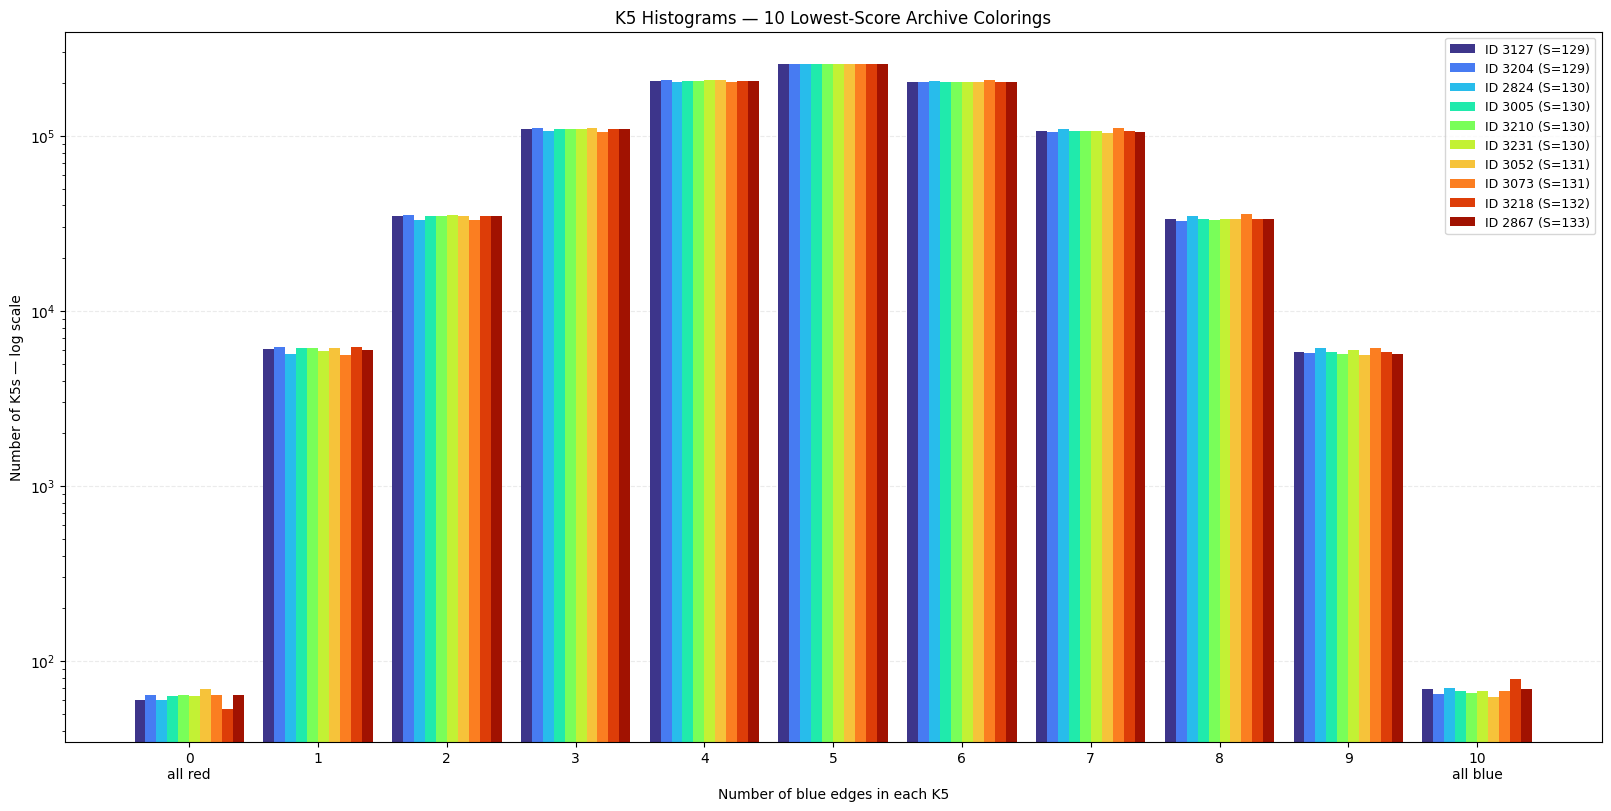

In [5]:
fig, ax = plt.subplots(
    figsize=(16, 8),
    constrained_layout=True,
)

bins = np.arange(11)

number_of_graphs = len(best_colorings)
group_width = 0.85
bar_width = group_width / number_of_graphs

colors = plt.colormaps["turbo"](
    np.linspace(
        0.05,
        0.95,
        number_of_graphs,
    )
)

for index, (archived, color) in enumerate(
    zip(best_colorings, colors)
):
    offset = (
        index
        - (number_of_graphs - 1) / 2
    ) * bar_width

    ax.bar(
        bins + offset,
        archived.histogram,
        width=bar_width,
        color=color,
        label=(
            f"ID {archived.record.coloring_id} "
            f"(S={archived.record.score})"
        ),
    )

ax.set_yscale("log")

ax.set_xticks(bins)

ax.set_xticklabels([
    "0\nall red",
    "1",
    "2",
    "3",
    "4",
    "5",
    "6",
    "7",
    "8",
    "9",
    "10\nall blue",
])

ax.set_xlabel(
    "Number of blue edges in each K5"
)

ax.set_ylabel(
    "Number of K5s — log scale"
)

ax.set_title(
    "K5 Histograms — 10 Lowest-Score Archive Colorings"
)

ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.25,
)

ax.set_axisbelow(True)

ax.legend(
    fontsize=9,
)

plt.show()